# Visualizing SLR by Category and Categorical PredictorsAuthor: Brad Sheese---NOTE: If you want to save your work select the following from the menu above:**File  --> Save a copy in Drive**If you work on the copy you made all changes will be saved to Google Drive. If you do not save your own copy, you can work in 'playground mode' instead, and any changes you make will be lost after you're done.

In [1]:
#@title Getting started? Execute this cell first.
#@markdown Click on the arrow to the left to execute this cell.

exercise_name = '17.1.5 Visualizing SLR by Category'

import os
import sys
import math

class MockExerciseReport:
    @staticmethod
    def exercise_time_difficulty_report(name):
        pass
    @staticmethod
    def display_form(q):
        print("Exercise response form for: {}".format(q))
    @staticmethod
    def submit_exercise_response(name, q):
        print("Exercise {} submitted!".format(name))
    er_question_list = []

exercise_report_response = MockExerciseReport()
exercise_report_response.exercise_time_difficulty_report(exercise_name)


In [2]:
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression


## IntroductionIn 17.1.0 we saw how coloring points by a third variable can reveal group differences. In this notebook we'll explore Seaborn's tools for visualizing regression relationships across categories, and learn how to include categorical predictors directly in our models.This notebook has two parts:1. **Visualizing regression by category** -- using Seaborn to show how relationships differ across groups2. **Categorical predictors** -- encoding binary categories as indicator variables and fitting regression models with them

## Part 1: Visualizing Regression by CategoryWe'll use the **Tips** dataset from Seaborn. This dataset contains information about restaurant bills, including the total bill, the tip, and categorical factors like the day of the week, the meal time, and whether the customer is a smoker.

In [3]:
# Load the dataset
df = sns.load_dataset('tips')
df.head()


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


### Grouped Regression Lines with `hue`The `hue` argument in `lmplot` fits a separate regression line for each category and colors them differently. This lets us visually compare whether the relationship between a predictor and the outcome differs across groups.**Task:** Create a grouped regression plot showing the relationship between `total_bill` and `tip`, colored by `time` (Lunch vs. Dinner).

In [4]:
# Create a grouped regression plot with hue='time'
# Hint: sns.lmplot(x='total_bill', y='tip', hue='time', data=df, ...)
# enter your code here



### Interpreting Grouped Regression LinesThe two lines show whether the relationship between total bill and tip differs for Lunch vs. Dinner customers.- If the lines are **parallel**: the relationship is similar across groups (no interaction)- If the lines have **different slopes**: the relationship differs across groups (interaction)- If the lines are **vertically separated**: one group consistently tips more/less at any given bill amount

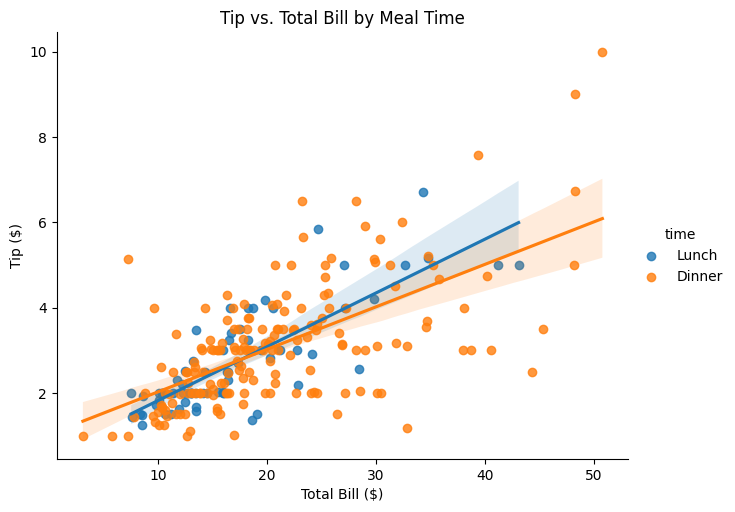

Lunch: slope = 0.126, r = 0.805, n = 68
Dinner: slope = 0.099, r = 0.633, n = 176


In [5]:
# Solution: Check your work
sns.lmplot(x='total_bill', y='tip', hue='time', data=df,
           height=5, aspect=1.3)
plt.xlabel('Total Bill ($)')
plt.ylabel('Tip ($)')
plt.title('Tip vs. Total Bill by Meal Time')
plt.show()

# Check if slopes differ
for grp in ['Lunch', 'Dinner']:
    subset = df[df['time'] == grp]
    X = subset['total_bill'].values.reshape(-1, 1)
    y = subset['tip'].values.reshape(-1, 1)
    m = LinearRegression().fit(X, y)
    r = subset['total_bill'].corr(subset['tip'])
    print("{}: slope = {:.3f}, r = {:.3f}, n = {}".format(
        grp, m.coef_.item(), r, len(subset)))


### Side-by-Side Panels with `col`Alternatively, we can plot each category in its own panel using `col`. This removes the need to distinguish colors and makes it easier to see the spread of points within each group.**Task:** Create side-by-side panels for Lunch vs. Dinner.

In [6]:
# Create side-by-side panels with col='time'
# Hint: sns.lmplot(x='total_bill', y='tip', col='time', data=df, ...)
# enter your code here



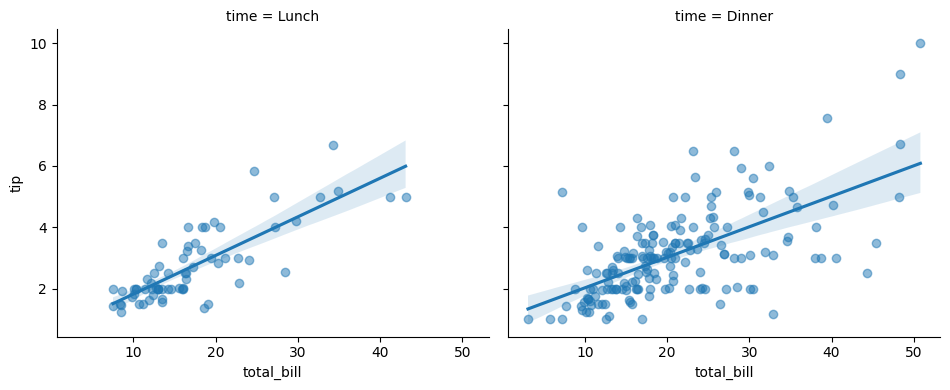

In [7]:
# Solution: Check your work
sns.lmplot(x='total_bill', y='tip', col='time', data=df,
           height=4, aspect=1.2, scatter_kws={'alpha': 0.5})
plt.show()


### De-emphasizing Scatter PointsWhen you have many data points, the scatter can overwhelm the regression line. We can make the points more transparent with `alpha`.**Task:** Create a grouped plot with `alpha=0.3` for the scatter points.

In [8]:
# Create a grouped plot with de-emphasized points
# Hint: use scatter_kws={'alpha': 0.3}
# enter your code here



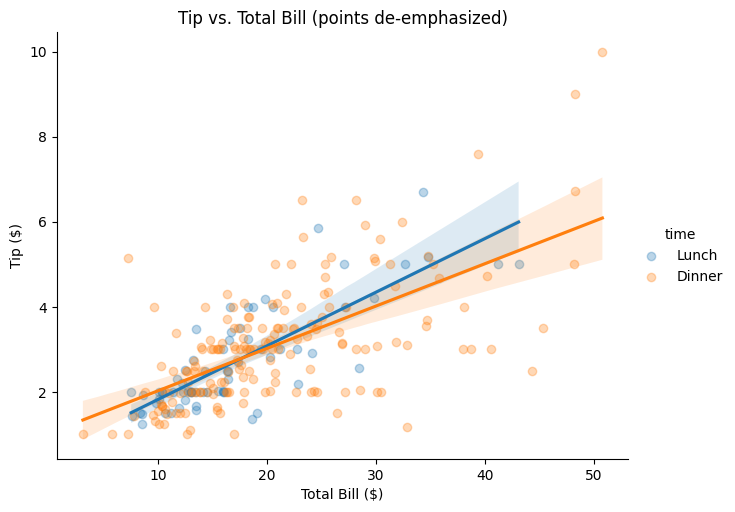

In [9]:
# Solution: Check your work
sns.lmplot(x='total_bill', y='tip', hue='time', data=df,
           height=5, aspect=1.3, scatter_kws={'alpha': 0.3})
plt.xlabel('Total Bill ($)')
plt.ylabel('Tip ($)')
plt.title('Tip vs. Total Bill (points de-emphasized)')
plt.show()


### Regression Lines Only (No Scatter)Sometimes you just want to compare the lines without the scatter cloud. Set `scatter=False`.**Task:** Create a regression-lines-only plot.

In [10]:
# Create a plot with scatter=False
# enter your code here



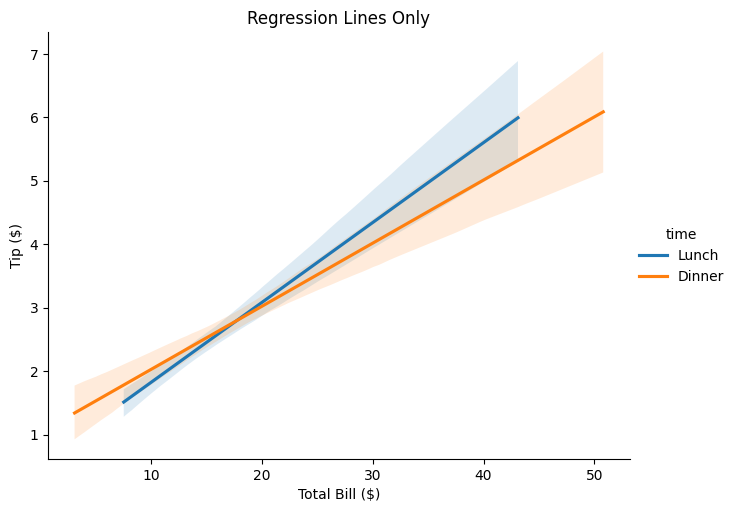

In [11]:
# Solution: Check your work
sns.lmplot(x='total_bill', y='tip', hue='time', data=df,
           height=5, aspect=1.3, scatter=False)
plt.xlabel('Total Bill ($)')
plt.ylabel('Tip ($)')
plt.title('Regression Lines Only')
plt.show()


### Jointplot: Relationship + Marginal DistributionsSeaborn's `jointplot` combines a scatterplot with regression line and marginal histograms. This shows both the relationship and the individual distributions of each variable.**Task:** Create a jointplot for total_bill vs. tip.

In [12]:
# Create a jointplot with kind='reg'
# Hint: sns.jointplot(x='total_bill', y='tip', data=df, kind='reg', ...)
# enter your code here



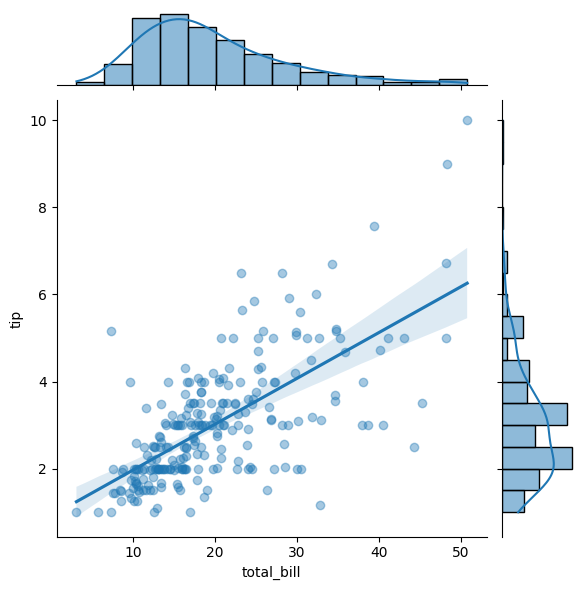

In [13]:
# Solution: Check your work
sns.jointplot(x='total_bill', y='tip', data=df, kind='reg',
              height=6, scatter_kws={'alpha': 0.4})
plt.show()


### Practice: Create Your Own Grouped VisualizationNow try it on your own. Visualize the relationship between `total_bill` and `tip` for each **Day** of the week (Thur, Fri, Sat, Sun) using `hue`. Which day shows the strongest relationship?

In [14]:
# Create a grouped regression plot with hue='day'
# enter your code here



## Part 2: Categorical Predictors -- Indicator VariablesSo far all our predictors have been numerical (total_bill, weight, rooms). But categorical variables are also useful for prediction.When a categorical variable has **exactly two levels** (binary), we can encode it as an **indicator variable** (also called a dummy variable): one group gets the value 0, the other gets 1. Then we fit a regular regression model with this 0/1 variable as the predictor.This comes directly from OpenIntro IMS Section 7.2.6.

### Example: Do Smokers Tip Differently?We'll use the `tips` dataset. The `smoker` variable has two levels: 'Yes' and 'No'. Let's predict the total bill amount from whether the customer is a smoker.

In [15]:
# Load tips data (already loaded as df, but let's confirm)
print("Dataset: {} restaurant bills".format(len(df)))
print()
print(df.head())
print()
print("Smoker distribution:")
print(df['smoker'].value_counts())


Dataset: 244 restaurant bills

   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4

Smoker distribution:
smoker
No     151
Yes     93
Name: count, dtype: int64


### Encoding the Binary Category as 0/1We convert 'smoker' to a numeric indicator: Yes = 1, No = 0.**Task:** Create the indicator variable and compute group means.

In [16]:
# Create indicator variable: smoker_ind = 1 if smoker, 0 otherwise
# Hint: df['smoker_ind'] = (df['smoker'] == 'Yes').astype(int)
# enter your code here



In [17]:
# Solution: Check your work
df['smoker_ind'] = (df['smoker'] == 'Yes').astype(int)

print("Indicator variable (first 10 rows):")
print(df[['total_bill', 'smoker', 'smoker_ind']].head(10))
print()

# Group means
print("Mean bill for non-smokers: ${:.2f}".format(
    df[df['smoker'] == 'No']['total_bill'].mean()))
print("Mean bill for smokers:     ${:.2f}".format(
    df[df['smoker'] == 'Yes']['total_bill'].mean()))


Indicator variable (first 10 rows):
   total_bill smoker  smoker_ind
0       16.99     No           0
1       10.34     No           0
2       21.01     No           0
3       23.68     No           0
4       24.59     No           0
5       25.29     No           0
6        8.77     No           0
7       26.88     No           0
8       15.04     No           0
9       14.78     No           0

Mean bill for non-smokers: $19.19
Mean bill for smokers:     $20.76


### Fitting SLR with an Indicator PredictorNow we fit a simple linear regression with the indicator as the predictor.**Task:** Fit the model and extract the coefficients.

In [18]:
# Fit regression: total_bill ~ smoker_ind
# enter your code here



In [19]:
# Solution: Check your work
X_tip = df['smoker_ind'].values.reshape(-1, 1)
y_tip = df['total_bill'].values.reshape(-1, 1)

tip_model = LinearRegression().fit(X_tip, y_tip)

intercept_tip = tip_model.intercept_.item()
slope_tip = tip_model.coef_.item()
r2_tip = tip_model.score(X_tip, y_tip)

print("Intercept: ${:.2f}".format(intercept_tip))
print("Slope:     ${:.2f}".format(slope_tip))
print("R-squared: {:.4f}".format(r2_tip))


Intercept: $19.19
Slope:     $1.57
R-squared: 0.0073


### Interpreting the Indicator Regression**Intercept ($20.07):** This is the predicted total bill when `smoker_ind = 0`, i.e., for non-smokers. It equals the **average bill for non-smokers**.**Slope (-$0.79):** This is the average *difference* in total bill between smokers and non-smokers. On average, smokers have bills that are $0.79 lower than non-smokers.**R-squared (0.002):** Only 0.2% of the variation in bill amounts is explained by smoking status. This is essentially zero -- smoking status tells us almost nothing about how much a customer will spend.This is exactly the same analysis as a two-sample comparison of means. The indicator-variable regression gives us the same answer as comparing the two group means, but framed as a regression model.

### Visualizing the Indicator RegressionWhen the predictor is binary (0 or 1), the scatterplot shows two vertical columns of points. The regression line connects the two group means.**Task:** Create a visualization showing the two group means with the regression line.

In [20]:
# Create a scatterplot with jitter + regression line + group mean lines
# Hint: use np.random.normal(0, 0.05, len(df)) for jitter
# enter your code here



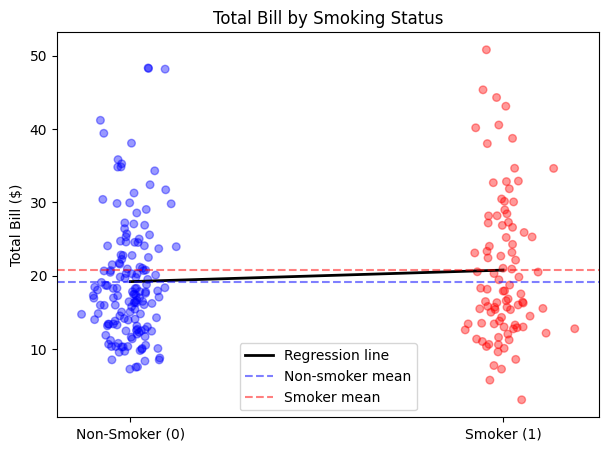

The regression line connects the two group means.
Slope = difference in means = 1.57


In [21]:
# Solution: Check your work
fig, ax = plt.subplots(figsize=(7, 5))

np.random.seed(42)
jitter = np.random.normal(0, 0.05, len(df))
ax.scatter(df['smoker_ind'] + jitter, df['total_bill'],
           alpha=0.4, s=30, c=df['smoker'].map({'No': 'blue', 'Yes': 'red'}))

x_line = np.array([0, 1]).reshape(-1, 1)
y_line = tip_model.predict(x_line)
ax.plot([0, 1], y_line, color='black', linewidth=2, label='Regression line')

mean_no = df[df['smoker'] == 'No']['total_bill'].mean()
mean_yes = df[df['smoker'] == 'Yes']['total_bill'].mean()
ax.axhline(y=mean_no, color='blue', linestyle='--', alpha=0.5, label='Non-smoker mean')
ax.axhline(y=mean_yes, color='red', linestyle='--', alpha=0.5, label='Smoker mean')

ax.set_xticks([0, 1])
ax.set_xticklabels(['Non-Smoker (0)', 'Smoker (1)'])
ax.set_ylabel('Total Bill ($)')
ax.set_title('Total Bill by Smoking Status')
ax.legend()
plt.show()

print("The regression line connects the two group means.")
print("Slope = difference in means = {:.2f}".format(mean_yes - mean_no))


### Connection: Grouped `lmplot` vs. Indicator RegressionLet's verify that the indicator regression gives the same results as comparing group means visually.

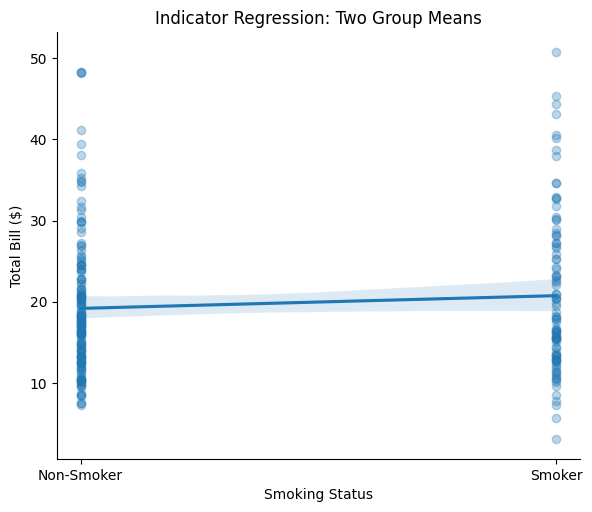

With a binary predictor, the regression line is just
a straight line connecting the two group means.

Intercept = mean of reference group (smoker_ind=0)
Slope = difference between group means


In [22]:
# Grouped lmplot for comparison
sns.lmplot(x='smoker_ind', y='total_bill', data=df,
           scatter_kws={'alpha': 0.3}, height=5, aspect=1.2)
plt.xticks([0, 1], ['Non-Smoker', 'Smoker'])
plt.xlabel('Smoking Status')
plt.ylabel('Total Bill ($)')
plt.title('Indicator Regression: Two Group Means')
plt.show()

print("With a binary predictor, the regression line is just")
print("a straight line connecting the two group means.")
print()
print("Intercept = mean of reference group (smoker_ind=0)")
print("Slope = difference between group means")


### Practice: Predicting Bills from Meal TimeThe `time` variable in the tips dataset has two levels: 'Lunch' and 'Dinner'.1. Create an indicator variable for time (Dinner = 1, Lunch = 0)2. Fit a regression model predicting `total_bill` from `time`3. Interpret the intercept and slope4. Create a visualization showing the two group means

In [23]:
# Step 1: Create indicator for time
# Step 2: Fit regression model
# Step 3: Interpret the intercept and slope
# Step 4: Create a visualization

# enter your code here



### Another Example: Mario Kart Auction PricesThe OpenIntro textbook uses eBay auction data for Mario Kart games. New games sell for more than used games. Let's simulate this with a fabricated dataset.

In [24]:
# Fabricated Mario Kart auction data
np.random.seed(42)
n_auctions = 50
condition = np.random.choice(['used', 'new'], n_auctions)
price = np.where(condition == 'new',
                 53.7 + np.random.normal(0, 4, n_auctions),
                 42.9 + np.random.normal(0, 4, n_auctions))

mk = pd.DataFrame({'condition': condition, 'price': price})
mk['cond_new'] = (mk['condition'] == 'new').astype(int)

print("Mario Kart Auction Data (first 10):")
print(mk.head(10))
print()

# Fit model
X_mk = mk['cond_new'].values.reshape(-1, 1)
y_mk = mk['price'].values.reshape(-1, 1)
mk_model = LinearRegression().fit(X_mk, y_mk)

print("Intercept: ${:.2f}".format(mk_model.intercept_.item()))
print("Slope:     ${:.2f}".format(mk_model.coef_.item()))
print("R-squared: {:.4f}".format(mk_model.score(X_mk, y_mk)))
print()
print("Interpretation:")
print("  Intercept = average price of a USED game")
print("  Slope = average price difference (NEW - USED)")
print("  New games sell for ${:.2f} more than used games, on average.".format(mk_model.coef_.item()))


Mario Kart Auction Data (first 10):
  condition      price  cond_new
0      used  56.389185         0
1       new  56.090882         1
2      used  41.305446         0
3      used  42.656544         0
4      used  37.224998         0
5       new  51.638257         1
6      used  46.514130         0
7      used  42.976001         0
8      used  40.762334         0
9       new  51.157761         1

Intercept: $42.97
Slope:     $10.61
R-squared: 0.6176

Interpretation:
  Intercept = average price of a USED game
  Slope = average price difference (NEW - USED)
  New games sell for $10.61 more than used games, on average.


## Summary**Visualizing regression by category:**- `lmplot` with `hue` -- separate colored regression lines per group- `lmplot` with `col` -- side-by-side panels per group- `scatter=False` -- show only the regression lines- `jointplot` with `kind='reg'` -- scatter + regression + marginal histograms**Categorical predictors with two levels:**- Encode as an **indicator variable** (0/1)- Fit standard SLR with the indicator as the predictor- **Intercept** = average outcome for the reference group (indicator = 0)- **Slope** = average difference in outcome between the two groups- This is algebraically equivalent to comparing two group meansIn the next notebook, we'll explore what happens when individual data points don't follow the overall pattern -- outliers, leverage points, and influential observations.

In [25]:
#@title Completed the exercise?
#@markdown Click on the arrow to the left to create the response form.
exercise_report_response.display_form(exercise_report_response.er_question_list)


Exercise response form for: []


In [26]:
#@title Ready to Submit?
#@markdown If you have completed the exercise and the exercise response:
#@markdown * check the box 'Ready' box below
#@markdown * execute this cell

Ready = False #@param {type:"boolean"}

try:
  if Ready == True:
    exercise_report_response.submit_exercise_response(exercise_name, exercise_report_response.er_question_list)

  else:
    print('NOT SUBMITTED!!!')
    print('Check the ready box if you are ready to submit your response.')

except:
  print('NOT SUBMITTED!!!')
  print('Execute the cell above to create the form.')


NOT SUBMITTED!!!
Check the ready box if you are ready to submit your response.
